### Let's load the tip data set

This dataset represents amount tipped (in dollars) with respect to certain characteristics of the tipper and the meal itself. 

In [3]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


Lets plot the frequency of tips in dollars

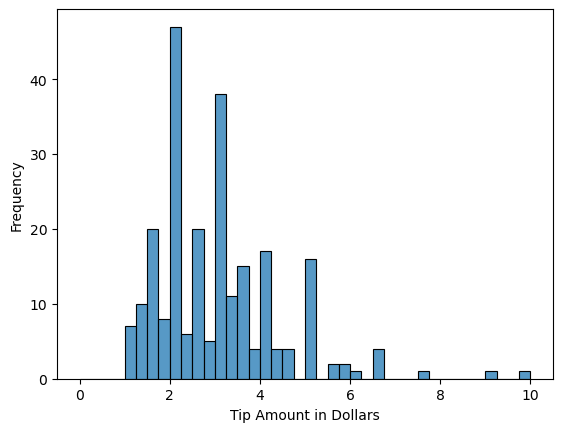

In [4]:
sns.histplot(data = tips['tip'], bins=np.arange(0, 10.1, 0.25))
plt.xlabel('Tip Amount in Dollars')
plt.ylabel('Frequency');

**What do you know notice about the distribution of tips?**

Add a column to the data frame that is the percentage tip that the customer paid.

In [6]:
tips.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

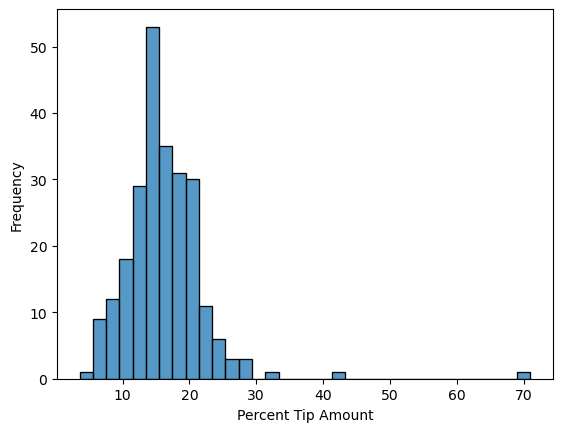

In [7]:
tips['pcttip'] = tips['tip'] / tips['total_bill'] * 100

sns.histplot(data = tips['pcttip'])
plt.xlabel('Percent Tip Amount')
plt.ylabel('Frequency');

Let's take a closer look once we eliminate the data for values of tips > 30% (i.e. our outliers).

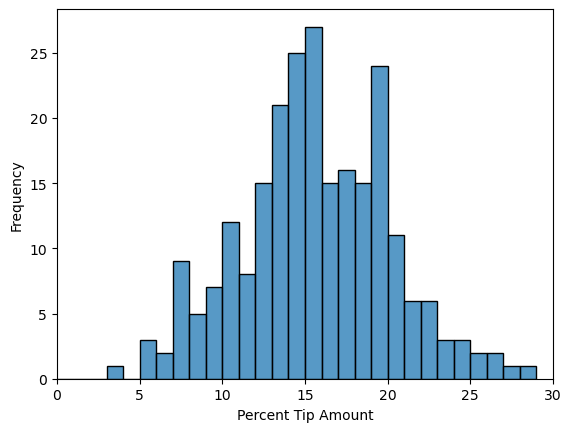

In [8]:
sns.histplot(tips['pcttip'], bins=np.arange(30))
plt.xlim(0, 30)
plt.xlabel('Percent Tip Amount')
plt.ylabel('Frequency');

**Now what do we notice about the distribution of percentage tips now?**

## Now let's use a constant model to describe our tips variable

We'll need to try different estimates of $\theta$ and assess associated loss to find the best model for our data. 

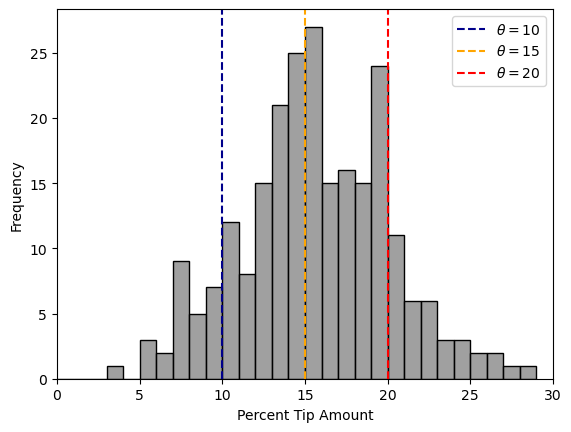

In [9]:
sns.histplot(tips['pcttip'], bins=np.arange(30), color = "gray")

plt.axvline(x=10, c='darkblue', linestyle='--', label=r'$ \theta = 10$')
plt.axvline(x=15, c='orange', linestyle='--', label=r'$ \theta = 15$')
plt.axvline(x=20, c='red', linestyle='--', label=r'$ \theta = 20$')
plt.legend()

plt.xlim(0, 30)
plt.xlabel('Percent Tip Amount')
plt.ylabel('Frequency');

Start with Mean Squared Error (MSE) to evaluate loss at different estimates of $\theta$

$L(\theta,\boldsymbol{y}) = \dfrac{1}{n}\sum_{i=1}^n (y_i - \theta)^2$

In [10]:
def mse_loss(theta, y_vals):
    return np.mean((y_vals - theta) ** 2)

Now we'll try different estimates for theta for a limited set of data (a single value of y, 14) and plot the results.

$l(\theta,y) = (y - \theta)^2$

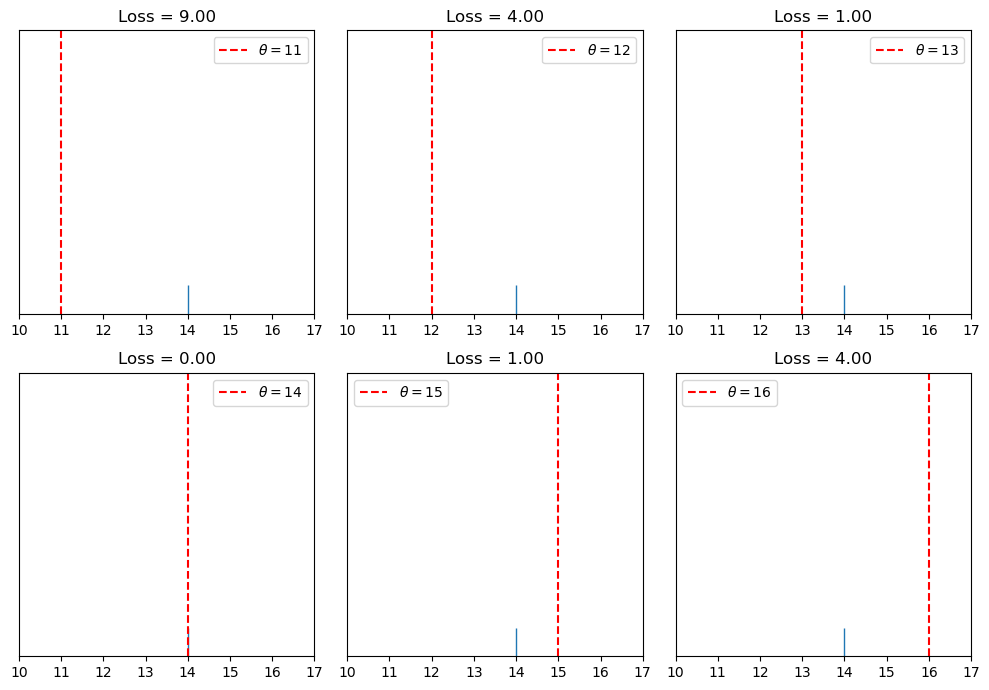

In [11]:
def try_thetas(thetas, y_vals, xlims, loss_fn=mse_loss, figsize=(10, 7), cols=3):
    
    y_vals = np.array(y_vals)
    theta = np.array(thetas)
    rows = int(np.ceil(len(thetas) / cols))
    
    plt.figure(figsize=figsize)
    
    for i in np.arange(0,len(thetas)):
        
        ax = plt.subplot(rows, cols, i + 1)
        sns.rugplot(y_vals, height=0.1, ax=ax)
        plt.axvline(theta[i], linestyle='--', color = "red",
                    label=rf'$ \theta = {theta[i]} $')
        plt.title(f'Loss = {loss_fn(theta[i], y_vals):.2f}')
        plt.xlim(xlims)
        plt.yticks([])
        plt.legend()
        
        plt.tight_layout()

try_thetas(thetas=[11, 12, 13, 14, 15, 16],
           y_vals=[14], xlims=[10, 17])

Next we try it with a set of 5 y values.

In [ ]:
try_thetas(thetas=[12, 13, 14, 15, 16, 17],
           y_vals=[11, 12, 15, 17, 18],
           xlims=(10.5, 18.5))

Now we try it with all of the values of percentage tip from the data set.

In [ ]:
try_thetas(thetas=np.arange(14.5, 17.1, 0.5),
           y_vals=tips['pcttip'],
           xlims=(0, 30))

Let's plot the loss function values for each value of theta for the limited set of y values and a limited set of theta values.

In [ ]:
thetas = np.array([12, 13, 14, 15, 16, 17])
y_vals = np.array([11, 12, 15, 17, 18])
losses = [mse_loss(theta, y_vals) for theta in thetas]

plt.scatter(thetas, losses)
plt.title(r'Loss vs. $ \theta $ when $\bf{y}$$ = [11, 12, 15, 17, 18] $')
plt.xlabel(r'$ \theta $ Values')
plt.ylabel('Loss');

Now let's plot the actual tip percentage data against a large number of theta values.

In [ ]:
thetas = np.arange(12, 20.1, 0.05)
y_vals = np.array(tips['pcttip'])
losses = [mse_loss(theta, y_vals) for theta in thetas]

plt.plot(thetas, losses)
plt.title(r'Loss vs. $ \theta $, all data')
plt.xlabel(r'$ \theta $ Values')
plt.ylabel('Loss');

**What's the rough value of $\theta$ that minimizes our loss function?**

When using MSE as our loss function with the Constant model, we already know that the mean of the variable is the $\theta$

In [ ]:
np.mean(tips['pcttip'])

Let's plot it up, showing the mean value as a red line.

In [ ]:
sns.histplot(tips['pcttip'], bins=np.arange(30))
sns.rugplot(tips['pcttip'], color = "black")

plt.axvline(x=16.08, color ='red', linestyle='--', label=r'$ \hat \theta = 16.08$')
plt.legend()

plt.xlim(0, 30)
plt.title('Distribution of tip percent')
plt.xlabel('Percent Tip Amount')
plt.ylabel('Proportion per Percent');

**In this case, is the mean an effective description of expectation in our data?**

### Mean absolute error

$L(\theta,\boldsymbol{y}) = \dfrac{1}{n}\sum_{i=1}^n |y_i - \theta|$

In [ ]:
def mae_loss(theta, y_vals):
    return np.mean(np.abs(y_vals - theta))
mae_loss(16, tips['pcttip'])

Compare MSE and MAE for a small set of thetas and a single y value.

In [ ]:
def compare_mse_abs(thetas, y_vals, xlims, loss_fn=mse_loss, figsize=(10, 7), cols=3):
    
    y_vals = np.array(y_vals)
    theta = np.array(thetas)
    rows = int(np.ceil(len(thetas) / cols))
    
    plt.figure(figsize=figsize)
    
    for i in np.arange(0,len(thetas)):
        
        ax = plt.subplot(rows, cols, i + 1)
        sns.rugplot(y_vals, height=0.1, ax=ax)
        plt.axvline(theta[i], linestyle='--', color = "red",
                    label=rf'$ \theta = {theta[i]} $')
        mse = mse_loss(theta[i], y_vals)
        mae = mae_loss(theta[i], y_vals)
        plt.title(f'MSE = {mse:.2f}\nMAE = {mae:.2f}')
        plt.xlim(xlims)
        plt.yticks([])
        plt.legend()
        
        plt.tight_layout()

compare_mse_abs(thetas=[11, 12, 13, 14, 15, 16],
                y_vals=[14], xlims=[10, 17])

In [ ]:
compare_mse_abs(thetas=[12, 13, 14, 15, 16, 17],
                y_vals=[12.1, 12.8, 14.9, 16.3, 17.2],
                xlims=(11, 18))

Plot MSE and MAE loss functions for a small number of thetas and a small number of y values.

In [ ]:
thetas = np.array([12, 13, 14, 15, 16, 17])
y_vals = np.array([12.1, 12.8, 14.9, 16.3, 17.2])
mse_losses = [mse_loss(theta, y_vals) for theta in thetas]
abs_losses = [mae_loss(theta, y_vals) for theta in thetas]

plt.scatter(thetas, mse_losses, label='MSE')
plt.scatter(thetas, abs_losses, label='MAE')
plt.title(r'Loss vs. $ \theta $ when $ \bf{y}$$= [ 12.1, 12.8, 14.9, 16.3, 17.2 ] $')
plt.xlabel(r'$ \theta $ Values')
plt.ylabel('Loss')
plt.legend();

Same as before with a much larger number of theta values.

In [ ]:
thetas = np.arange(12, 17.1, 0.05)
y_vals = np.array([12.1, 12.8, 14.9, 16.3, 17.2])
mse_losses = [mse_loss(theta, y_vals) for theta in thetas]
abs_losses = [mae_loss(theta, y_vals) for theta in thetas]

plt.plot(thetas, mse_losses, label='MSE')
plt.plot(thetas, abs_losses, label='MAE')
plt.title(r'Loss vs. $ \theta $ when $ \bf{y}$$ = [ 12.1, 12.8, 14.9, 16.3, 17.2 ] $')
plt.xlabel(r'$ \theta $ Values')
plt.ylabel('Loss')
plt.legend();

In the case of MAE with a Constant model, we already know that the median value of our variable is the value that minimizes $\theta$.

In [ ]:
thetas = np.arange(12, 17.1, 0.05)
y_vals = np.array([12.1, 12.8, 14.9, 16.3, 17.2])
mse_losses = [mse_loss(theta, y_vals) for theta in thetas]
abs_losses = [mae_loss(theta, y_vals) for theta in thetas]

plt.figure(figsize=(7, 5))
plt.plot(thetas, mse_losses, label='MSE')
plt.plot(thetas, abs_losses, label='MAE')
plt.axvline(np.mean(y_vals), c=sns.color_palette()[0], linestyle='--',
            alpha=0.7, label='Minimum MSE')
plt.axvline(np.median(y_vals), c=sns.color_palette()[1], linestyle='--',
            alpha=0.7, label='Minimum MAE')


plt.title(r'Loss vs. $ \theta $ when $ \bf{y}$$ = [ 12.1, 12.8, 14.9, 16.3, 17.2 ] $')
plt.xlabel(r'$ \theta $ Values')
plt.ylabel('Loss')
plt.ylim(1.5, 5)
plt.legend()
plt.tight_layout();

Let's look at MAE a little more closely. 

In [ ]:
def points_and_loss(y_vals, xlim, loss_fn=mae_loss):
    thetas = np.arange(xlim[0], xlim[1] + 0.01, 0.05)
    abs_losses = [loss_fn(theta, y_vals) for theta in thetas]
    
    plt.figure(figsize=(9, 2))
    
    ax = plt.subplot(121)
    sns.rugplot(y_vals, height=0.3, ax=ax)
    plt.xlim(*xlim)
    plt.xlabel('Points')
    
    ax = plt.subplot(122)
    plt.plot(thetas, abs_losses)
    plt.xlim(*xlim)
    plt.xlabel(r'$ \theta $')
    plt.ylabel('Loss')
points_and_loss(np.array([10, 11, 12, 14, 15]), (9, 16))

**What could happen if there are an even number of y-values?**

In [ ]:
points_and_loss(np.array([10, 11, 14, 15]), (9, 16))

**What's an important implication about MAE as a loss function here?**

No problem with MSE ...

In [ ]:
points_and_loss(np.array([10, 11, 14, 15]), (9, 16), mse_loss)

Both MSE and MAE are convex functions, meaning that any minimum value of the function will be a *global* minimum. This is very important in model fitting. However, watch out for multiple minimizing parameters with MAE. 

**Which loss function is better, MSE or MAE?**

### A quick point about loss gradients

In [ ]:
thetas = np.arange(12, 17.1, 0.05)
y_vals = np.array([12.1, 12.8, 14.9, 16.3, 17.2])
mse_losses = [mse_loss(theta, y_vals) for theta in thetas]
abs_losses = [mae_loss(theta, y_vals) for theta in thetas]

plt.plot(thetas, mse_losses, label='MSE')
plt.plot(thetas, abs_losses, label='MAE')
plt.title(r'Loss vs. $ \theta $ when $ \bf{y}$$ = [ 12.1, 12.8, 14.9, 16.3, 17.2 ] $')
plt.xlabel(r'$ \theta $ Values')
plt.ylabel('Loss')
plt.legend();

In terms of which loss function best optimizes our model, we can make arguments for both MSE and MAE.

However, a quadratic gradient of the form given to us by MSE has some additional advantages when it comes to the fitting process by which we algorithmically identify parameters that minimize loss *i.e.* **gradient descent**.

### Huber loss - parameterized loss function that splices MSE and MAE according to the alpha parameter

In [ ]:
def huber_loss(est, y_obs, alpha = 1):
    d = np.abs(est - y_obs)
    return np.where(d < alpha, 
                    (est - y_obs)**2 / 2.0,
                    alpha * (d - alpha / 2.0))

thetas = np.linspace(0, 50, 200)
loss = huber_loss(thetas, np.array([14]), alpha=5)
plt.plot(thetas, loss, label="Huber Loss")
plt.vlines(np.array([14]), -20, -5,colors="r", label="Observation")
plt.xlabel(r"Choice for $\theta$")
plt.ylabel(r"Loss")
plt.legend()

In [ ]:
loss = huber_loss(thetas, np.array([14]), alpha=1)
plt.plot(thetas, loss, label="Huber Loss")
plt.vlines(np.array([14]), -20, -5,colors="r", label="Observation")
plt.xlabel(r"Choice for $\theta$")
plt.ylabel(r"Loss")
plt.legend()

In [ ]:
loss = huber_loss(thetas, np.array([14]), alpha=10)
plt.plot(thetas, loss, label="Huber Loss")
plt.vlines(np.array([14]), -20, -5,colors="r", label="Observation")
plt.xlabel(r"Choice for $\theta$")
plt.ylabel(r"Loss")
plt.legend()

Huber loss curves as a function of alpha for a single y value

In [ ]:
colors = ['blue', 'green', 'black', 'brown', 'purple']
for alfa in range(1, 11, 2):
    loss = huber_loss(thetas, np.array([14]), alpha=alfa)
    plt.plot(thetas, loss, label="Huber Loss for alpha = {}".format(alfa), color=colors[alfa//2])
plt.vlines(np.array([14]), -20, -5,colors="r", label="Observation")
plt.xlabel(r"Choice for $\theta$")
plt.ylabel(r"Loss")
plt.legend()